In [1]:
%matplotlib ipympl

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import RangeSlider
from datetime import datetime
from datetime import timezone

In [2]:
PRESSURE_LOG    = "./moderator_heatup/Pressure_2026-03-13_15-42-36.log"    # or None
TEMPERATURE_LOG = "./moderator_heatup/Temp_2026-03-13_15-43-02.log" # or None



In [3]:
def load_csv(path, col_indices):
    col_map = {c: [] for c in col_indices}
    timestamps = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = [p.strip() for p in line.split(",")]
            try:
                ts = float(parts[0])
                vals = {c: float(parts[c]) for c in col_indices if c < len(parts) and parts[c]}
                if len(vals) == len(col_indices):
                    timestamps.append(ts)
                    for c, v in vals.items():
                        col_map[c].append(v)
            except (ValueError, IndexError):
                continue
    return np.array(timestamps), {c: np.array(col_map[c]) for c in col_indices}

def to_dt(ts):
    return [datetime.utcfromtimestamp(t) for t in ts]

In [4]:
pres_data = temp_data = None

if PRESSURE_LOG:
    ts, v = load_csv(PRESSURE_LOG, [1])
    pres_data = (ts, v[1])

if TEMPERATURE_LOG:
    ts, v = load_csv(TEMPERATURE_LOG, [1, 2])
    temp_data = (ts, v[1], v[2])

C:\Users\keert\AppData\Local\Temp\ipykernel_26804\1022604258.py:22: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return [datetime.utcfromtimestamp(t) for t in ts]


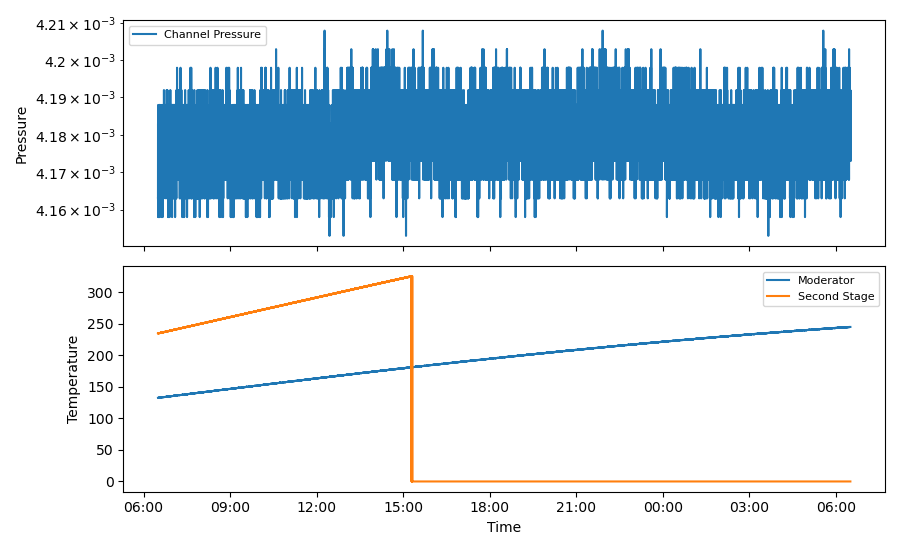

In [11]:
# Set to None to show everything
T_START = datetime(2026, 3, 14, 6, 30, tzinfo=timezone.utc).timestamp()
T_END   = datetime(2026, 3, 15, 6, 30, tzinfo=timezone.utc).timestamp()
#T_START = None
#T_END   = None

n = (1 if pres_data else 0) + (1 if temp_data else 0)
fig, axs = plt.subplots(n, 1, figsize=(9, 2.5 * n + 0.5), sharex=True)
if n == 1:
    axs = [axs]

fmt = mdates.DateFormatter("%H:%M")
i = 0

all_ts = [d[0] for d in [pres_data, temp_data] if d]
lo = T_START if T_START else min(a[0] for a in all_ts)
hi = T_END   if T_END   else max(a[-1] for a in all_ts)

if pres_data:
    ts, p = pres_data
    mask = (ts >= lo) & (ts <= hi)
    axs[i].plot(to_dt(ts[mask]), p[mask], label="Channel Pressure")
    axs[i].set_ylabel("Pressure")
    axs[i].set_yscale("log")
    axs[i].legend(fontsize=8)
    i += 1

if temp_data:
    ts, mod, cold = temp_data
    mask = (ts >= lo) & (ts <= hi)
    axs[i].plot(to_dt(ts[mask]), mod[mask], label="Moderator")
    axs[i].plot(to_dt(ts[mask]), cold[mask], label="Second Stage")
    axs[i].set_ylabel("Temperature")
    axs[i].legend(fontsize=8)

axs[-1].set_xlabel("Time")
axs[-1].xaxis.set_major_formatter(fmt)
axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator())

fig.tight_layout()
plt.show()